<a href="https://colab.research.google.com/github/Lucas-Rodrigues-code/Lucas-Rodrigues-code/blob/main/Analisando_os_Dados_do_Airbnb_New_York.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Análise dos Dados do Airbnb - *New York*

O [Airbnb](https://www.airbnb.com.br/) já é considerado como sendo a **maior empresa hoteleira da atualidade**. Ah, o detalhe é que ele **não possui nenhum hotel**!

Conectando pessoas que querem viajar (e se hospedar) com anfitriões que querem alugar seus imóveis de maneira prática, o Airbnb fornece uma plataforma inovadora para tornar essa hospedagem alternativa.

No final de 2018, a Startup fundada 10 anos atrás, já havia **hospedado mais de 300 milhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais.

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/get-the-data.html), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de *Data Science*.

<center><img alt="Analisando Airbnb" width="10%" src="https://www.area360.com.au/wp-content/uploads/2017/09/airbnb-logo.jpg"></center>

**Neste *notebook*, iremos analisar os dados referentes à cidade ________, e ver quais insights podem ser extraídos a partir de dados brutos.**

## Obtenção dos Dados


In [ ]:
# importar os pacotes necessarios
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [ ]:
# importar o arquivo listings.csv para um DataFrame
df =  pd.read_csv('http://data.insideairbnb.com/united-states/ny/new-york-city/2021-08-04/visualisations/listings.csv')


## Análise dos Dados


**Dicionário das variáveis**

* ... id - número de id gerado para identificar o imóvel
* ... name - nome da propriedade anunciada
* ... host_id - número de id do proprietário (anfitrião) da propriedade
* ... host_name - Nome do anfitrião
* ... neighbourhood_group - esta coluna não contém nenhum valor válido
* ... neighbourhood - nome do bairro
* ... latitude - coordenada da latitude da propriedade
* ... longitude - coordenada da longitude da propriedade
* ... room_type - informa o tipo de quarto que é oferecido
* ... price - preço para alugar o imóvel
* ... minimum_nights - quantidade mínima de noites para reservar
* ... number_of_reviews - número de reviews que a propriedade possui
* ... last_review - data do último review
* ... reviews_per_month - quantidade de reviews por mês
* ... calculated_host_listings_count - quantidade de imóveis do mesmo anfitrião
* ... availability_365 - número de dias de disponibilidade dentro de 365 dias

Antes de iniciar qualquer análise, vamos verificar a cara do nosso *dataset*, analisando as 5 primeiras entradas.

In [ ]:
# mostrar as 5 primeiras entradas
df.head(5)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,150,30,48,2019-11-04,0.34,3,341
1,3831,"Whole flr w/private bdrm, bath & kitchen(pls r...",4869,LisaRoxanne,Brooklyn,Bedford-Stuyvesant,40.68494,-73.95765,Entire home/apt,75,1,408,2021-06-29,5.09,1,212
2,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68535,-73.95512,Private room,60,30,50,2016-06-05,0.55,1,365
3,5136,"Spacious Brooklyn Duplex, Patio + Garden",7378,Rebecca,Brooklyn,Sunset Park,40.66265,-73.99454,Entire home/apt,275,5,1,2014-01-02,0.01,1,184
4,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Midtown,40.76457,-73.98317,Private room,61,2,485,2021-07-18,3.63,1,255


Nesse primeiro contato com nosso dataset, ele não aparente ter dados ausentes, vamos explorar mais um pouco 🔎







### **Q1. Quantos atributos (variáveis) e quantas entradas o nosso conjunto de dados possui? Quais os tipos das variáveis?**

In [ ]:
# identificar o volume de dados do DataFrame
print('Linhas e colunas {} '.format(df.shape))

# verificar as 5 primeiras entradas do dataset
df.dtypes


Linhas e colunas (36724, 16) 


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Temos 36.724 mil entradas em 16 variáveis

*   A maioria das entradas são numéricas 




### **Q2. Qual a porcentagem de valores ausentes no *dataset*?**

In [ ]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes
(df.isnull().sum() / df.shape[0]).sort_values(ascending=False)*100
                                


reviews_per_month                 25.637185
last_review                       25.637185
host_name                          0.062629
name                               0.035399
availability_365                   0.000000
calculated_host_listings_count     0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
price                              0.000000
room_type                          0.000000
longitude                          0.000000
latitude                           0.000000
neighbourhood                      0.000000
neighbourhood_group                0.000000
host_id                            0.000000
id                                 0.000000
dtype: float64

Temos relativamente poucos dados ausentes nas colunas


1.  reviews_per_month, 25% ausentes 
2.  last_review , 25 % ausentes 
3.  host_name, 0,06 % ausentes 
4.  name, 0,03 % ausentes 

As duas últimas ausentes têm valores tão baixos que podem ser descartadas. O restante das colunas todas estão com valores completos




### **Q3. Qual o tipo de distribuição das variáveis?** 

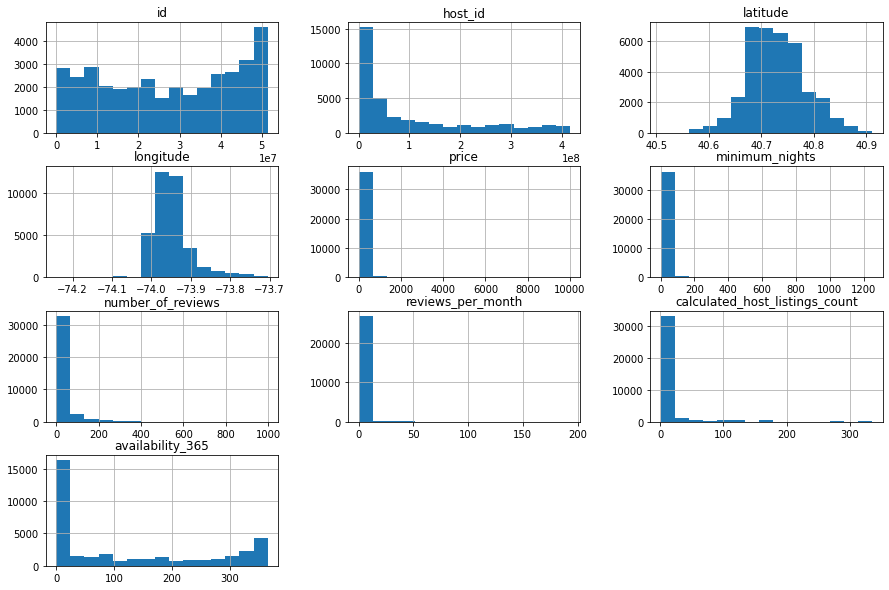

In [ ]:
# plotar o histograma das variáveis numéricas
df.hist(bins=15, figsize=(15,10));


Pela distribuição do histograma, é possível verificar indícios da presença de outliers. Olhe por exemplo as variáveis price, minimum_nights.
Os valores não seguem uma distruição, e distorcem toda a representação gráfica. Vamos ver um resumo estatÍstico por meio do metodo describe()

In [ ]:
df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,36724.000000,36724.000000,36724.000000,27309.000000,36724.000000,36724.000000
mean,160.109057,22.482083,22.854836,1.375435,13.432306,122.570608
std,293.888431,28.361534,49.188479,3.850175,46.293004,138.765815
min,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,67.000000,3.000000,0.000000,0.110000,1.000000,0.000000
50%,108.000000,30.000000,4.000000,0.420000,1.000000,57.000000
75%,175.000000,30.000000,19.000000,1.450000,3.000000,259.000000
max,10000.000000,1250.000000,998.000000,192.930000,335.000000,365.000000


Se prestarmos atenção nos valores máximos "MAX", veremos que quase 100% da variaiveis apresentar outliers. Vamos plotar um box plot com a variavel "price" para exemplificar.
Creio eu que esses valores sejam em dolares, procurando no próprio site do airbnb os valores mais altos que achei em Nova york, foi algo próximo de 3500 dolares por noite, vamos considerar qualquer valor acima outliers 

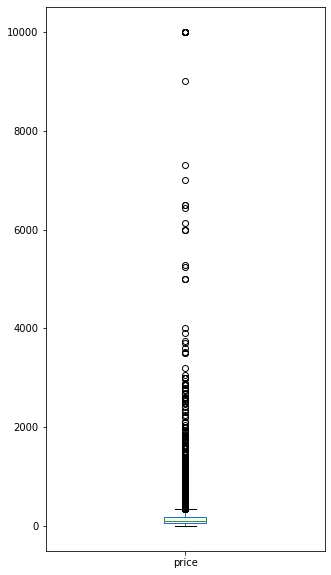

In [ ]:
df.price.plot(kind="box",figsize=(5,10)); 

A alguns valores acima de 3500 dolares no preço, vamos retirar esses valores.

In [ ]:
print('valores maiores que 3500')
print('{} maiores que 3500'.format(len(df[df.price > 3500])))

valores maiores que 3500
35 maiores que 3500


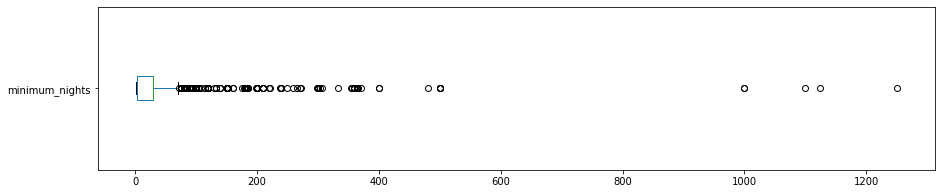

In [ ]:
df.minimum_nights.plot(kind='box', vert= False, figsize=(15,3));

No variável 'minimum_nights' também a presença de outliers, vamos considerar qualquer valor acima de 30 noites um outlier.

In [ ]:
print('{} maiores que 30'.format(len(df[df.minimum_nights > 30])))

1342 maiores que 30


In [ ]:
# limpando o dataset tirando os outliers das colinas price e minium_nights
df_limpo = df.copy()
df_limpo.drop(df_limpo[df_limpo.price > 3500].index, axis=0,inplace=True)
df_limpo.drop(df_limpo[df_limpo.minimum_nights > 30].index, axis=0,inplace=True)


In [ ]:
df_limpo.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.535300e+04,3.535300e+04,35353.000000,35353.000000,35353.000000,35353.000000,35353.000000,26581.000000,35353.000000,35353.000000
mean,2.720718e+07,1.055354e+08,40.729446,-73.949332,153.264193,19.676944,23.236302,1.398078,13.418267,120.589596
std,1.631909e+07,1.218130e+08,0.055744,0.049970,176.859954,13.141583,49.530302,3.897737,46.736999,138.242235
min,2.595000e+03,2.420000e+03,40.508630,-74.241350,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,1.228428e+07,1.063860e+07,40.689520,-73.983100,68.000000,3.000000,1.000000,0.110000,1.000000,0.000000
50%,2.767787e+07,4.573139e+07,40.725590,-73.954850,108.000000,30.000000,4.000000,0.430000,1.000000,52.000000
75%,4.275744e+07,1.739659e+08,40.762870,-73.931160,175.000000,30.000000,20.000000,1.480000,3.000000,254.000000
max,5.145137e+07,4.162927e+08,40.911380,-73.705220,3500.000000,30.000000,998.000000,192.930000,335.000000,365.000000


### **Q4. Qual a média dos preços de aluguel?**

In [ ]:
# ver a média da coluna `price``
print('A média do aluguel é {}'.format(round(df_limpo.price.mean(),2)))

A média do aluguel é 153.26


### **Q4. Qual a correlação existente entre as variáveis**

In [ ]:
# criar uma matriz de correlação
correlação = df_limpo[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].corr()
display(correlação)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.000000,-0.068563,-0.042322,0.001108,0.011442,0.103833
minimum_nights,-0.068563,1.000000,-0.267676,-0.289668,0.143089,-0.151174
number_of_reviews,-0.042322,-0.267676,1.000000,0.327702,-0.102554,0.113040
reviews_per_month,0.001108,-0.289668,0.327702,1.000000,-0.005165,0.120963
calculated_host_listings_count,0.011442,0.143089,-0.102554,-0.005165,1.000000,0.245984
availability_365,0.103833,-0.151174,0.113040,0.120963,0.245984,1.000000


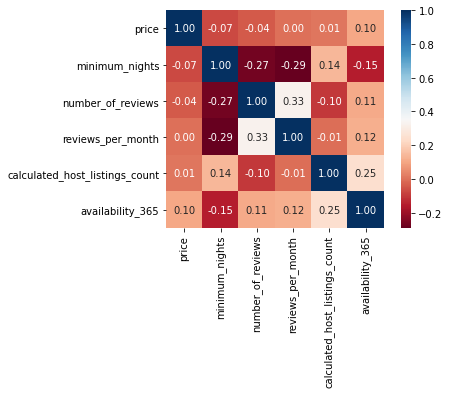

In [ ]:
# plotar um heatmap a partir das correlações
sns.heatmap(correlação, cmap='RdBu', fmt='.2f', square=True, linecolor='white', annot=True);


### **Q5. Qual o tipo de imóvel mais alugado no Airbnb?**

In [ ]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_limpo.room_type.value_counts()


Entire home/apt    18664
Private room       15860
Shared room          571
Hotel room           258
Name: room_type, dtype: int64

In [ ]:
# mostrar a porcentagem de cada tipo de imóvel disponível
df_limpo.room_type.value_counts() / df_limpo.shape[0]*100


Entire home/apt    52.793257
Private room       44.861822
Shared room         1.615139
Hotel room          0.729782
Name: room_type, dtype: float64

Temos um grandes número de casas completas e quartos privados.

### **Q6. Qual a localidade mais cara do dataset?**



In [ ]:
# ver preços por bairros, na média
df_limpo.groupby(['neighbourhood']).price.mean().sort_values(ascending=False)[:10]


neighbourhood
Fort Wadsworth       800.000000
Riverdale            520.125000
Prince's Bay         397.500000
Tribeca              356.388158
Flatiron District    352.253521
Tottenville          350.000000
Theater District     309.680702
Willowbrook          309.000000
SoHo                 281.812000
Midtown              278.278758
Name: price, dtype: float64

Fort Wadsworth ocupa o lugar mais caro, com uma média de 800 dolares por dia 

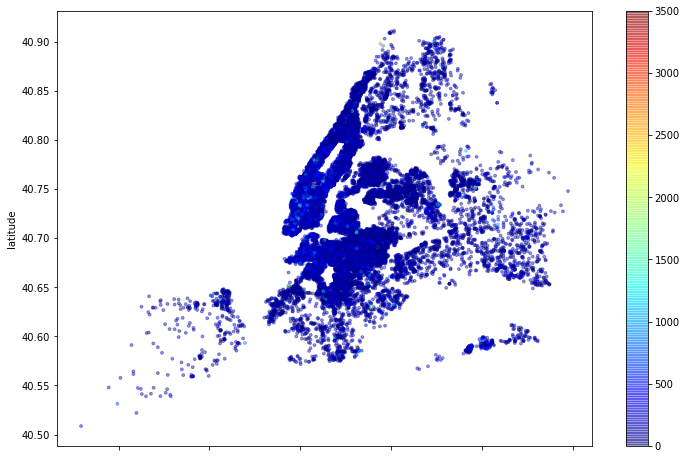

In [ ]:
# plotar os imóveis pela latitude-longitude
df_limpo.plot(kind='scatter', x = 'longitude', y ='latitude',alpha=0.4, c=df_limpo['price'], s=8, cmap=plt.get_cmap('jet'), figsize=(12,8) );

Podemos ver que a maior concentração de imóveis para alugar são no Brooklyn, Queens e Manhattan 

### **Q7. Qual é a média do mínimo de noites para aluguel (minimum_nights)?**

In [ ]:
# ver a média da coluna `minimum_nights``
print('A média fica em {}'.format(round(df_limpo.minimum_nights.mean(),2)))

A média fica em 19.68


## Conclusões


Podemos ver nos dados que a cidade de Nova York tem muitos imóveis para serem alugados ao total de 36724 mil imóveis, tomamos  como principais variáveis para analisar o dataset “price’ e “ minimum_nights” . De acordo com a análise  os preços de aluguel variam de  uma média de 153 dólares por dia até 3500 dólares. Com a maioria dos imóveis sendo apartamentos completos sendo alugados em média por 19 dias e uma máximo de 30 dias, também podemos notar que a regiões mais caras ficam em Fort Wadsworth, Riverdale, Prince's Bay.